# Universidad del Valle de Guatemala
## CC3092 - Deep Learning
## Hoja de trabajo 2

# DCGAN desde cero. Generación de sprites de Pokémon

**Integrantes:** 
- Dulce Ambrosio - 231143
- Angie Vela - 23764
---
## Descripcion general

Implementación de una DCGAN con PyTorch para generar sprites de Pokémon de 64×64 RGB. 
El dataset se construye a partir del repositorio público de sprites de PokeAPI en 
GitHub (898 imágenes, todas las generaciones).



# TASK 1
---

## 0. Configuración e imports

In [1]:
import os
import time
import random
import requests
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

Usando device: cuda


In [2]:
# Parametros fijos del enunciado
Z_DIM = 100
IMG_SIZE = 64
IMG_CHANNELS = 3
FEATURES_G = 64
FEATURES_D = 64

# Hiperparametros de entrenamiento
BATCH_SIZE = 32
NUM_EPOCHS = 50
LR = 2e-4
BETAS = (0.5, 0.999)

DATA_DIR = "pokemon_sprites"
OUT_DIR = "outputs"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Dataset — descarga de sprites desde PokeAPI (GitHub)

Si ya cuenta con el script proporcionado en la plataforma para construir el
dataset, puede usarlo directamente y saltar a la sección "Carga del dataset".
La celda siguiente es una alternativa autocontenida que descarga los sprites
`front_default` oficiales del repositorio público `PokeAPI/sprites`
(carpeta `sprites/pokemon`) para las 898 especies (Pokédex nacional hasta
Gen 8) y las guarda localmente redimensionadas a 64×64.

In [3]:
from PIL import Image

SPRITES_BASE_URL = (
    "https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon"
)
N_POKEMON = 898  # Pokedex nacional completa hasta Gen 8


def download_pokemon_sprites(n=N_POKEMON, out_dir=DATA_DIR, size=IMG_SIZE):
    """Descarga los sprites front_default de PokeAPI y los guarda como PNG
    RGB de (size x size) en out_dir. Omite descargas ya existentes, por lo
    que la celda se puede volver a correr sin costo extra."""
    downloaded, skipped, failed = 0, 0, 0
    for pid in range(1, n + 1):
        dst_path = os.path.join(out_dir, f"{pid:04d}.png")
        if os.path.exists(dst_path):
            skipped += 1
            continue
        url = f"{SPRITES_BASE_URL}/{pid}.png"
        try:
            resp = requests.get(url, timeout=15)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content)).convert("RGBA")

            # Componer sobre fondo blanco (los sprites tienen canal alpha)
            bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
            img = Image.alpha_composite(bg, img).convert("RGB")
            img = img.resize((size, size), Image.LANCZOS)
            img.save(dst_path)
            downloaded += 1
        except Exception as e:
            failed += 1
            print(f"  [!] fallo id={pid}: {e}")

        if pid % 100 == 0:
            print(f"  progreso: {pid}/{n}")

    print(f"Descarga completa. nuevas={downloaded} ya_existian={skipped} fallidas={failed}")


# Descomentar para descargar (requiere acceso a GitHub raw content)
download_pokemon_sprites()


Descarga completa. nuevas=0 ya_existian=898 fallidas=0


## 2. Carga del dataset

In [4]:
class PokemonSpriteDataset(Dataset):
    """Dataset de imagenes RGB 64x64 leidas de disco."""

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = sorted(
            f for f in os.listdir(root_dir) if f.lower().endswith(".png")
        )
        if len(self.files) == 0:
            raise RuntimeError(
                f"No se encontraron imagenes en '{root_dir}'. "
                "Corra la celda de descarga o el script de la plataforma primero."
            )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.root_dir, self.files[idx])
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img


# Normalizacion a [-1, 1] para que coincida con la salida Tanh del generador
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * IMG_CHANNELS, [0.5] * IMG_CHANNELS),
])

dataset = PokemonSpriteDataset(DATA_DIR, transform=transform)
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
)
print(f"Dataset cargado: {len(dataset)} imagenes, {len(dataloader)} batches/epoca")

Dataset cargado: 898 imagenes, 28 batches/epoca


## 3. Task 1.1 — Arquitectura

**Generador**: 5 capas `ConvTranspose2d` con canales
`[FEATURES_G*8, FEATURES_G*4, FEATURES_G*2, FEATURES_G, IMG_CHANNELS]`.
BatchNorm2d + ReLU después de cada capa excepto la última (Tanh).

**Discriminador**: 5 capas `Conv2d` con stride 2 y canales
`[FEATURES_D, FEATURES_D*2, FEATURES_D*4, FEATURES_D*8, 1]`.
BatchNorm2d + LeakyReLU(0.2) después de cada capa excepto la primera y la
última (Sigmoid).

In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, features_g=FEATURES_G, img_channels=IMG_CHANNELS):
        super().__init__()
        self.net = nn.Sequential(
            # z: (batch, z_dim, 1, 1) -> (batch, features_g*8, 4, 4)
            self._block(z_dim, features_g * 8, kernel=4, stride=1, padding=0),
            # -> (batch, features_g*4, 8, 8)
            self._block(features_g * 8, features_g * 4, kernel=4, stride=2, padding=1),
            # -> (batch, features_g*2, 16, 16)
            self._block(features_g * 4, features_g * 2, kernel=4, stride=2, padding=1),
            # -> (batch, features_g, 32, 32)
            self._block(features_g * 2, features_g, kernel=4, stride=2, padding=1),
            # -> (batch, img_channels, 64, 64)
            nn.ConvTranspose2d(
                features_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False
            ),
            nn.Tanh(),
        )

    @staticmethod
    def _block(in_c, out_c, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, features_d=FEATURES_D, img_channels=IMG_CHANNELS):
        super().__init__()
        self.net = nn.Sequential(
            # (batch, img_channels, 64, 64) -> (batch, features_d, 32, 32)
            # primera capa: sin BatchNorm (regla de Radford et al.)
            nn.Conv2d(img_channels, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, features_d*2, 16, 16)
            self._block(features_d, features_d * 2, kernel=4, stride=2, padding=1),
            # -> (batch, features_d*4, 8, 8)
            self._block(features_d * 2, features_d * 4, kernel=4, stride=2, padding=1),
            # -> (batch, features_d*8, 4, 4)
            self._block(features_d * 4, features_d * 8, kernel=4, stride=2, padding=1),
            # -> (batch, 1, 1, 1) : ultima capa, sin BatchNorm, con Sigmoid
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid(),
        )

    @staticmethod
    def _block(in_c, out_c, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    """Inicializacion recomendada por Radford et al. (2015): N(0, 0.02)."""
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [6]:
# Verificacion de formas exactas (requerimiento del enunciado)
G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

z = torch.randn(4, Z_DIM, 1, 1, device=device)
assert G(z).shape == (4, 3, 64, 64), "Forma del generador incorrecta"
assert D(torch.randn(4, 3, 64, 64, device=device)).shape == (4,), "Forma del discriminador incorrecta"
print("Formas verificadas correctamente.")
print(G)
print(D)

Formas verificadas correctamente.
Generator(
  (net): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stat

## 4. Task 1.2 — Entrenamiento alternado

Por cada batch:

1. **Paso del discriminador** (maximizar $\theta_D$): pérdida sobre reales con
   etiqueta 1 + pérdida sobre falsas (`.detach()`) con etiqueta 0. Se suman y
   se actualiza $\theta_D$.
2. **Paso del generador** (minimizar $\theta_G$, truco de Goodfellow): nuevas
   imágenes falsas evaluadas por $D$ con etiqueta 1 (quiere engañar a $D$).

`BCELoss`, `Adam(lr=2e-4, betas=(0.5, 0.999))` para ambas redes,
`batch_size=32`, 50 épocas.

In [7]:
criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

# Ruido fijo para visualizar la evolucion del generador a lo largo del entrenamiento
FIXED_NOISE = torch.randn(16, Z_DIM, 1, 1, device=device)

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

history = {"loss_G": [], "loss_D": []}
snapshot_grids = []  # una grilla 4x4 por epoca (con FIXED_NOISE)

In [8]:
def train_one_epoch():
    G.train()
    D.train()
    epoch_loss_G, epoch_loss_D = 0.0, 0.0

    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # -------------------------------------------------
        # Paso del discriminador: max log(D(x)) + log(1 - D(G(z)))
        # -------------------------------------------------
        opt_D.zero_grad()

        real_labels = torch.full((b_size,), REAL_LABEL, device=device)
        pred_real = D(real_imgs)
        loss_D_real = criterion(pred_real, real_labels)

        noise = torch.randn(b_size, Z_DIM, 1, 1, device=device)
        fake_imgs = G(noise)
        fake_labels = torch.full((b_size,), FAKE_LABEL, device=device)
        # detach() para NO propagar gradiente hacia G en este paso
        pred_fake = D(fake_imgs.detach())
        loss_D_fake = criterion(pred_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # -------------------------------------------------
        # Paso del generador: min log(1 - D(G(z)))  ==  max log(D(G(z)))
        # (truco de Goodfellow: usar etiquetas reales para el gradiente de G)
        # -------------------------------------------------
        opt_G.zero_grad()

        pred_fake_for_G = D(fake_imgs)  # sin detach: el gradiente si fluye a G
        gen_labels = torch.full((b_size,), REAL_LABEL, device=device)
        loss_G = criterion(pred_fake_for_G, gen_labels)
        loss_G.backward()
        opt_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    n_batches = len(dataloader)
    return epoch_loss_G / n_batches, epoch_loss_D / n_batches

In [9]:
start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    avg_loss_G, avg_loss_D = train_one_epoch()
    history["loss_G"].append(avg_loss_G)
    history["loss_D"].append(avg_loss_D)

    with torch.no_grad():
        G.eval()
        fake_grid = G(FIXED_NOISE).detach().cpu()
        G.train()
    snapshot_grids.append(fake_grid)

    grid = vutils.make_grid(fake_grid, nrow=4, normalize=True, value_range=(-1, 1))
    vutils.save_image(grid, os.path.join(OUT_DIR, f"epoch_{epoch:03d}.png"))

    print(
        f"Epoca [{epoch:02d}/{NUM_EPOCHS}] "
        f"loss_G={avg_loss_G:.4f}  loss_D={avg_loss_D:.4f}  "
        f"({time.time() - start:.1f}s transcurridos)"
    )

torch.save(G.state_dict(), os.path.join(OUT_DIR, "generator_final.pt"))
torch.save(D.state_dict(), os.path.join(OUT_DIR, "discriminator_final.pt"))
print("Entrenamiento finalizado. Pesos guardados en outputs/.")

Epoca [01/50] loss_G=10.6750  loss_D=0.3621  (2.8s transcurridos)
Epoca [02/50] loss_G=15.2402  loss_D=0.7800  (4.8s transcurridos)
Epoca [03/50] loss_G=11.1658  loss_D=1.5490  (6.8s transcurridos)
Epoca [04/50] loss_G=7.6258  loss_D=0.6617  (8.6s transcurridos)
Epoca [05/50] loss_G=8.4884  loss_D=0.5588  (10.3s transcurridos)
Epoca [06/50] loss_G=6.3773  loss_D=0.2198  (12.2s transcurridos)
Epoca [07/50] loss_G=6.2976  loss_D=0.1906  (14.1s transcurridos)
Epoca [08/50] loss_G=6.8520  loss_D=0.7762  (15.9s transcurridos)
Epoca [09/50] loss_G=4.6937  loss_D=0.3744  (17.7s transcurridos)
Epoca [10/50] loss_G=6.0662  loss_D=0.6247  (19.6s transcurridos)
Epoca [11/50] loss_G=5.9614  loss_D=0.3983  (21.9s transcurridos)
Epoca [12/50] loss_G=5.8144  loss_D=0.2836  (23.8s transcurridos)
Epoca [13/50] loss_G=6.1209  loss_D=0.2267  (25.6s transcurridos)
Epoca [14/50] loss_G=7.1759  loss_D=0.8482  (27.5s transcurridos)
Epoca [15/50] loss_G=5.6405  loss_D=0.2983  (29.4s transcurridos)
Epoca [16/5

## 5. Task 1.3 — Visualizaciones

### 5.1 Grilla 4×4 de imágenes generadas al final del entrenamiento
(desnormalizadas de [-1, 1] a [0, 255])

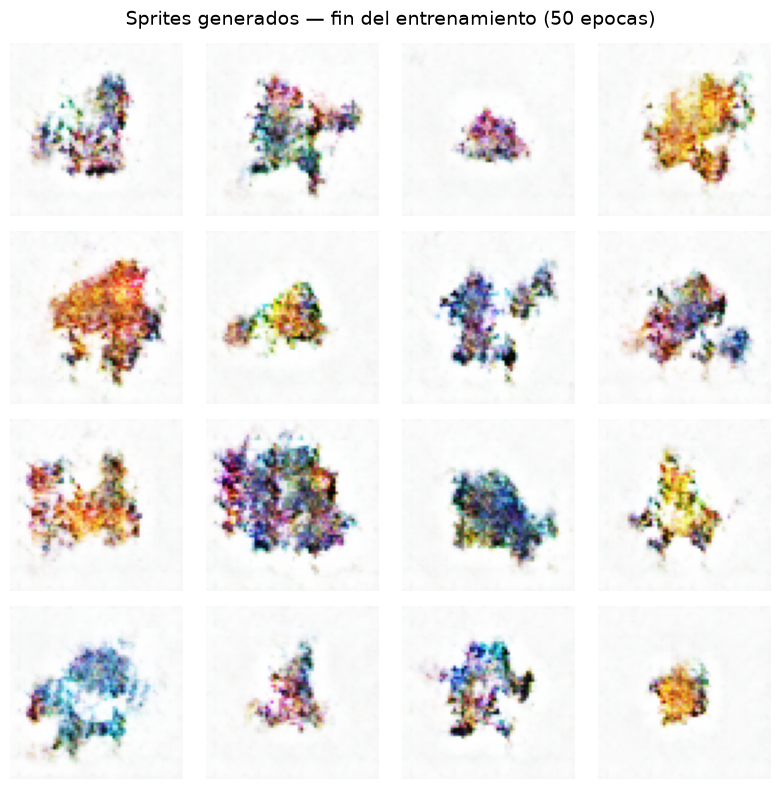

In [10]:
with torch.no_grad():
    G.eval()
    final_fake = G(FIXED_NOISE).detach().cpu()
    G.train()

# Desnormalizar de [-1, 1] a [0, 255]
final_imgs = (final_fake + 1) / 2.0  # -> [0, 1]
final_imgs = (final_imgs * 255).clamp(0, 255).to(torch.uint8)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for idx, ax in enumerate(axes.flat):
    img = final_imgs[idx].permute(1, 2, 0).numpy()  # (H, W, C)
    ax.imshow(img)
    ax.axis("off")

fig.suptitle("Sprites generados — fin del entrenamiento (50 epocas)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "grid_final_4x4.png"), dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Curvas de loss_G y loss_D a lo largo de las 50 épocas

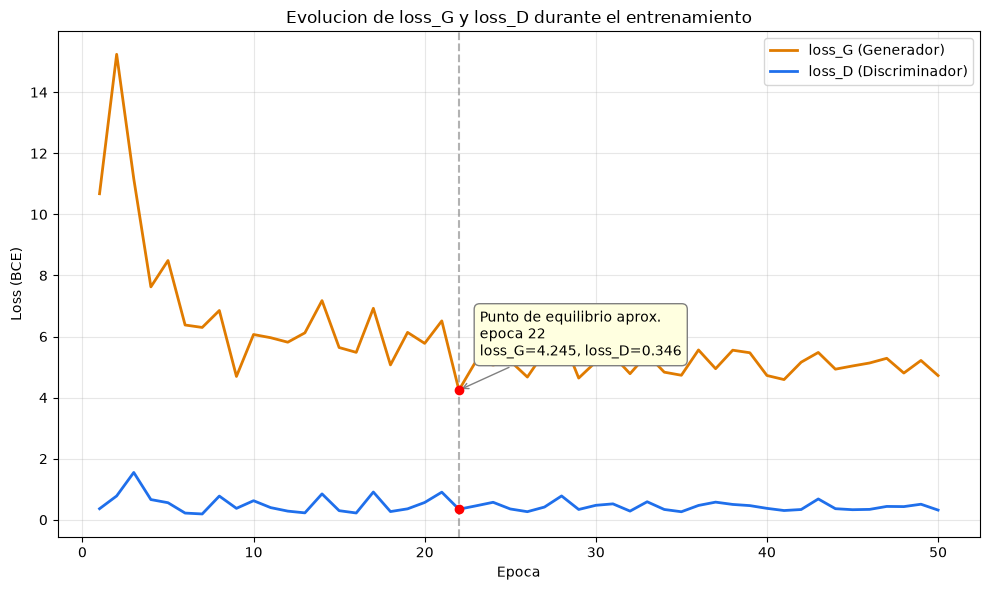

Punto mas cercano entre loss_G y loss_D: epoca 22 (|diff|=3.8988)


In [11]:
epochs = np.arange(1, NUM_EPOCHS + 1)
loss_G_arr = np.array(history["loss_G"])
loss_D_arr = np.array(history["loss_D"])

# Punto donde las perdidas estan mas cerca entre si (proxy de equilibrio)
diff = np.abs(loss_G_arr - loss_D_arr)
closest_idx = int(np.argmin(diff))
closest_epoch = epochs[closest_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs, loss_G_arr, label="loss_G (Generador)", color="#e07b00", linewidth=2)
ax.plot(epochs, loss_D_arr, label="loss_D (Discriminador)", color="#1f6feb", linewidth=2)

ax.axvline(closest_epoch, color="gray", linestyle="--", alpha=0.6)
ax.scatter(
    [closest_epoch, closest_epoch],
    [loss_G_arr[closest_idx], loss_D_arr[closest_idx]],
    color="red",
    zorder=5,
)
ax.annotate(
    f"Punto de equilibrio aprox.\nepoca {closest_epoch}\n"
    f"loss_G={loss_G_arr[closest_idx]:.3f}, loss_D={loss_D_arr[closest_idx]:.3f}",
    xy=(closest_epoch, max(loss_G_arr[closest_idx], loss_D_arr[closest_idx])),
    xytext=(15, 25),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="gray"),
    arrowprops=dict(arrowstyle="->", color="gray"),
)

ax.set_xlabel("Epoca")
ax.set_ylabel("Loss (BCE)")
ax.set_title("Evolucion de loss_G y loss_D durante el entrenamiento")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

print(
    f"Punto mas cercano entre loss_G y loss_D: epoca {closest_epoch} "
    f"(|diff|={diff[closest_idx]:.4f})"
)

# TASK 2
---


## Task 2.1 — Inducción deliberada del mode collapse

Se modifica el balance de entrenamiento del Task 1.2: en lugar de 1 paso de $D$ por
1 paso de $G$, se entrena **5 pasos de $D$ por cada 1 paso de $G$**, durante **20 épocas**.

Para no perder los pesos entrenados en el Task 1 (que se necesitan en el Task 2.2),
se instancian un generador y un discriminador **nuevos** (`G_mc`, `D_mc`) dedicados
exclusivamente a este experimento.

In [12]:
# ---------------------------------------------------------------
# Modelos nuevos (independientes de G, D del Task 1) para no perder
# los pesos entrenados que se necesitan en el Task 2.2
# ---------------------------------------------------------------
G_mc = Generator().to(device)
D_mc = Discriminator().to(device)
G_mc.apply(weights_init)
D_mc.apply(weights_init)

opt_G_mc = optim.Adam(G_mc.parameters(), lr=LR, betas=BETAS)
opt_D_mc = optim.Adam(D_mc.parameters(), lr=LR, betas=BETAS)

NUM_EPOCHS_MC = 20
D_STEPS_PER_G = 5

FIXED_NOISE_MC = torch.randn(16, Z_DIM, 1, 1, device=device)
history_mc = {"loss_G": [], "loss_D": []}
snapshot_grids_mc = []


def train_one_epoch_collapse():
    # Entrena D_mc 5 pasos por cada 1 paso de G_mc (desbalance deliberado).
    G_mc.train()
    D_mc.train()

    sum_loss_D, n_d_steps = 0.0, 0
    sum_loss_G, n_g_steps = 0.0, 0

    for batch_idx, real_imgs in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # -------------------------------------------------
        # Paso del discriminador (se ejecuta SIEMPRE)
        # -------------------------------------------------
        opt_D_mc.zero_grad()

        real_labels = torch.full((b_size,), REAL_LABEL, device=device)
        pred_real = D_mc(real_imgs)
        loss_D_real = criterion(pred_real, real_labels)

        noise = torch.randn(b_size, Z_DIM, 1, 1, device=device)
        fake_imgs = G_mc(noise)
        fake_labels = torch.full((b_size,), FAKE_LABEL, device=device)
        pred_fake = D_mc(fake_imgs.detach())
        loss_D_fake = criterion(pred_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D_mc.step()

        sum_loss_D += loss_D.item()
        n_d_steps += 1

        # -------------------------------------------------
        # Paso del generador: SOLO cada D_STEPS_PER_G pasos de D
        # -------------------------------------------------
        if (batch_idx + 1) % D_STEPS_PER_G == 0:
            opt_G_mc.zero_grad()

            noise_g = torch.randn(b_size, Z_DIM, 1, 1, device=device)
            fake_imgs_g = G_mc(noise_g)
            pred_fake_for_G = D_mc(fake_imgs_g)
            gen_labels = torch.full((b_size,), REAL_LABEL, device=device)
            loss_G = criterion(pred_fake_for_G, gen_labels)
            loss_G.backward()
            opt_G_mc.step()

            sum_loss_G += loss_G.item()
            n_g_steps += 1

    avg_loss_D = sum_loss_D / max(n_d_steps, 1)
    avg_loss_G = sum_loss_G / max(n_g_steps, 1)
    return avg_loss_G, avg_loss_D


start_mc = time.time()
for epoch in range(1, NUM_EPOCHS_MC + 1):
    avg_loss_G, avg_loss_D = train_one_epoch_collapse()
    history_mc["loss_G"].append(avg_loss_G)
    history_mc["loss_D"].append(avg_loss_D)

    with torch.no_grad():
        G_mc.eval()
        fake_grid = G_mc(FIXED_NOISE_MC).detach().cpu()
        G_mc.train()
    snapshot_grids_mc.append(fake_grid)

    print(
        f"[Mode collapse] Epoca [{epoch:02d}/{NUM_EPOCHS_MC}] "
        f"(5 pasos D : 1 paso G)  "
        f"loss_G={avg_loss_G:.4f}  loss_D={avg_loss_D:.4f}  "
        f"({time.time() - start_mc:.1f}s transcurridos)"
    )

print("Entrenamiento con desbalance 5:1 (D:G) finalizado.")


[Mode collapse] Epoca [01/20] (5 pasos D : 1 paso G)  loss_G=7.9402  loss_D=0.0944  (1.7s transcurridos)
[Mode collapse] Epoca [02/20] (5 pasos D : 1 paso G)  loss_G=9.2248  loss_D=0.0066  (3.4s transcurridos)
[Mode collapse] Epoca [03/20] (5 pasos D : 1 paso G)  loss_G=10.2749  loss_D=0.0038  (5.1s transcurridos)
[Mode collapse] Epoca [04/20] (5 pasos D : 1 paso G)  loss_G=11.8351  loss_D=0.2373  (6.5s transcurridos)
[Mode collapse] Epoca [05/20] (5 pasos D : 1 paso G)  loss_G=47.6677  loss_D=0.1297  (7.9s transcurridos)
[Mode collapse] Epoca [06/20] (5 pasos D : 1 paso G)  loss_G=47.6154  loss_D=0.0001  (9.3s transcurridos)
[Mode collapse] Epoca [07/20] (5 pasos D : 1 paso G)  loss_G=47.6168  loss_D=0.0002  (10.7s transcurridos)
[Mode collapse] Epoca [08/20] (5 pasos D : 1 paso G)  loss_G=47.6042  loss_D=0.0001  (12.3s transcurridos)
[Mode collapse] Epoca [09/20] (5 pasos D : 1 paso G)  loss_G=47.5677  loss_D=0.0001  (13.7s transcurridos)
[Mode collapse] Epoca [10/20] (5 pasos D : 1 

### Grilla 4×4 — evidencia visual del mode collapse

Se generan las mismas 16 imágenes con `FIXED_NOISE_MC` al final de las 20 épocas. Si el
mode collapse ocurrió, las 16 imágenes deben lucir prácticamente idénticas (o con
variaciones triviales de color/textura), en contraste con la diversidad observada en el
Task 1.3.

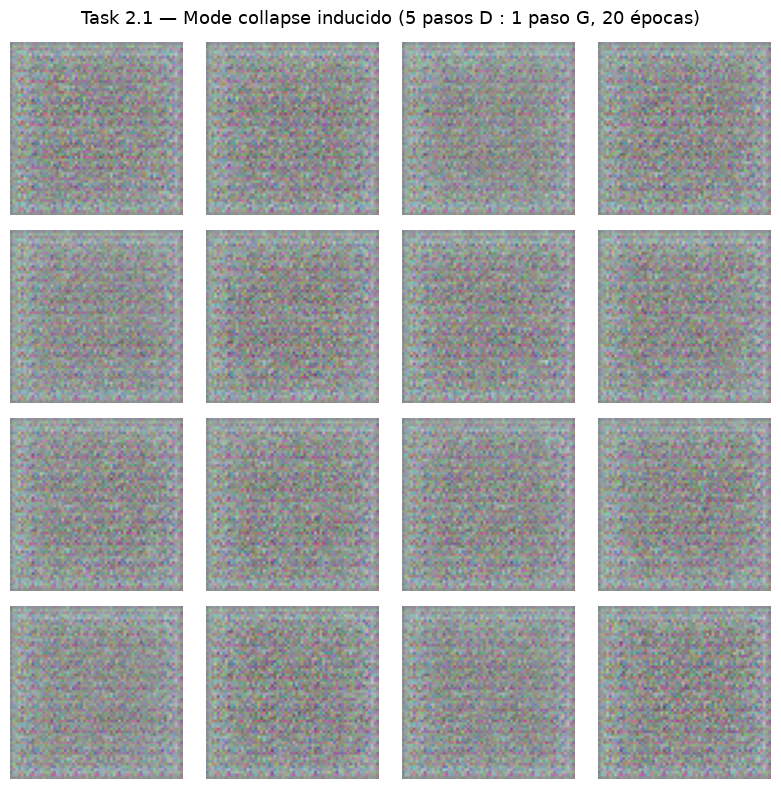

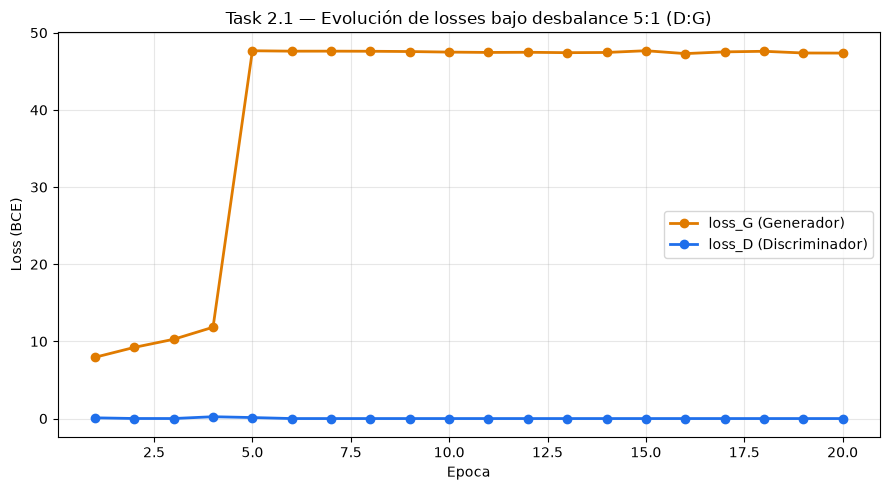

In [13]:
with torch.no_grad():
    G_mc.eval()
    final_fake_mc = G_mc(FIXED_NOISE_MC).detach().cpu()
    G_mc.train()

final_imgs_mc = (final_fake_mc + 1) / 2.0
final_imgs_mc = (final_imgs_mc * 255).clamp(0, 255).to(torch.uint8)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for idx, ax in enumerate(axes.flat):
    img = final_imgs_mc[idx].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis("off")

fig.suptitle(
    "Task 2.1 — Mode collapse inducido (5 pasos D : 1 paso G, 20 épocas)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "grid_mode_collapse_4x4.png"), dpi=150, bbox_inches="tight")
plt.show()

# Curvas de loss del experimento de mode collapse
epochs_mc = np.arange(1, NUM_EPOCHS_MC + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs_mc, history_mc["loss_G"], label="loss_G (Generador)", color="#e07b00", linewidth=2, marker="o")
ax.plot(epochs_mc, history_mc["loss_D"], label="loss_D (Discriminador)", color="#1f6feb", linewidth=2, marker="o")
ax.set_xlabel("Epoca")
ax.set_ylabel("Loss (BCE)")
ax.set_title("Task 2.1 — Evolución de losses bajo desbalance 5:1 (D:G)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curves_mode_collapse.png"), dpi=150, bbox_inches="tight")
plt.show()


### Respuestas Task 2.1

**a) ¿Por qué entrenar $D$ muchas más veces que $G$ induce el mode collapse?**

Con el truco de Goodfellow (etiquetas reales para el paso de $G$), la pérdida del
generador es $\mathcal{L}_G=-\mathbb{E}_z[\log D(G(z))]$, y con `BCELoss` (que ya incluye
el sigmoide dentro de $D$) su gradiente respecto a $\theta_G$ es, por regla de la cadena:

$$
\nabla_{\theta_G}\mathcal{L}_G
= -\,\mathbb{E}_z\!\left[\frac{1}{D(G(z))}\,\nabla_x D(x)\Big|_{x=G(z)}\;J_G(z)\right]
$$

donde $J_G(z)=\partial G(z)/\partial\theta_G$. Al entrenar $D$ cinco veces por cada
actualización de $G$, $D$ se acerca mucho más a su punto óptimo local $D^*$ para el
$G$ actual, y aprende a **rechazar con altísima confianza** casi todas las salidas de
$G$: $D(G(z))\approx 0$ para prácticamente todo $z$. Esto produce dos efectos que se
combinan:

1. El factor $1/D(G(z))$ se dispara ($\to\infty$) cuando $D(G(z))\to 0$, generando
   gradientes de magnitud enorme y muy ruidosos (inestabilidad numérica) en las pocas
   direcciones donde $D$ todavía no es perfectamente plano.
2. En la mayor parte del espacio de salida, el sigmoide de $D$ está **saturado**
   (firmemente en la región donde su salida es $\approx 0$), así que
   $\nabla_x D(x)\big|_{x=G(z)}\approx 0$ ahí: $D$ ya no da ninguna señal útil sobre
   cómo mover $G(z)$ para mejorar.

El resultado neto es que el gradiente de $G$ deja de ser una señal suave que cubra
todo el espacio de salida y se concentra casi por completo en la(s) pocas regiones
donde $D$ todavía no está saturado, es decir, en la única grieta que por azar logra
producir $D(G(z))>0$ de forma numéricamente estable. Como todos los $z$ terminan
empujados hacia esa misma grieta, $G$ colapsa a producir prácticamente la misma
imagen para cualquier ruido de entrada.

El generador no puede recuperarse de este estado porque, una vez colapsado, todas
las salidas $G(z)$ caen en un vecindario minúsculo de la imagen. Cualquier gradiente
que $D$ le dé sobre ese vecindario solo puede mover a todo el generador dentro de
ese mismo vecindario (todas las salidas se mueven juntas, en la misma dirección),
porque los parámetros $\theta_G$ son compartidos por todos los $z$. No existe fuerza
alguna en $\mathcal{L}_G$ que empuje explícitamente hacia la diversidad entre
muestras; y como $D$ se re-entrena 5 veces más rápido que $G$, apenas $G$ intenta
explorar, $D$ ya volvió a aprender a rechazar esa nueva región, dejando a $G$
atrapado siguiendo el único gradiente local disponible en cada paso.

**b) Valor aproximado de $D^*(x)$ para las imágenes repetidas**

La fórmula del discriminador óptimo derivada en clase es:

$$
D^*(x) = \frac{p_{data}(x)}{p_{data}(x) + p_G(x)}
$$

En mode collapse, $p_G$ se concentra casi toda su masa de probabilidad en un
vecindario extremadamente pequeño del espacio de imágenes (las imágenes que $G$
repite una y otra vez). En ese punto exacto $x$, $p_G(x)$ es muy grande (masa
puntual/casi-delta), mientras que $p_{data}(x)$ (la densidad real de sprites de
Pokémon en exactamente ese punto) es comparativamente diminuta, porque los datos
reales están distribuidos entre cientos de sprites distintos y casi nunca coinciden
exactamente con la imagen degenerada que produce $G$. Por lo tanto:

$$
D^*(x) \approx \frac{p_{data}(x)}{p_{data}(x) + p_G(x)} \approx \frac{\text{pequeño}}{\text{pequeño}+\text{grande}} \approx 0
$$

Esto es consistente con lo observado: como $D$ se entrena 5 veces más, rápidamente
vuelve a "descubrir" que esas imágenes repetidas son falsas y las empuja a
$D(x)\approx 0$, lo cual se refleja en un `loss_D` bajo (D gana fácilmente) y un
`loss_G` alto y volátil en las curvas de arriba.

**c) Modificación concreta para prevenir el mode collapse (sin tocar la proporción de pasos)**

Proponemos agregar **minibatch discrimination / minibatch standard deviation** al
discriminador. Antes de la última capa, se calcula la desviación estándar de las
activaciones a través de todas las imágenes del minibatch (real o falso) y se
concatena como un feature adicional que $D$ recibe junto con cada imagen.

Con esta modificación, $D(x_i)$ ya no depende únicamente de $x_i$ de forma aislada, 
sino también de qué tan parecidas son  $x_i$ y el resto del batch. 

Si $G$ colapsa y produce un batch de imágenes casi idénticas, la desviación estándar 
intra-batch será casi cero, lo cual es una señal que $D$ puede aprender a asociar con 
"batch falso" (los batches reales sí tienen diversidad). 

Esto crea un término explícito en $\nabla_{\theta_G}\mathcal{L}_G$ que
empuja a $G$ a aumentar la varianza entre muestras del mismo batch para seguir
engañando a $D$ (algo que la formulación original nunca puede penalizar). Por ende, 
convierte la falta de diversidad en una señal de gradiente explícita y persistente, 
en lugar de dejar que sea un efecto secundario accidental del entrenamiento.

## Task 2.2 
### Estimación empírica de la divergencia Jensen-Shannon

Se utiliza el **discriminador entrenado en la Parte 1.2** (`D`, entrenado 1:1 durante
las `NUM_EPOCHS` épocas del Task 1) junto con los valores de `loss_G` y `loss_D`
registrados en `history` durante ese mismo entrenamiento.

Como en el training loop `loss_D = loss_D_real + loss_D_fake`, y cada término de
`BCELoss` es exactamente $-\log(\cdot)$ promediado sobre el batch, se cumple que:

$$
\text{loss\_D} = -\Big(\underbrace{\mathbb{E}[\log D(x)]}_{\text{término real}} + \underbrace{\mathbb{E}[\log(1-D(G(z)))]}_{\text{término falso}}\Big) \approx -V(D,G)
$$

Por lo tanto $V(D,G)\approx -\text{loss\_D}$, y el estimado de JSD queda:

$$
\widehat{\text{JSD}} = \frac{V(D,G) + \log 4}{2} \approx \frac{-\text{loss\_D} + \log 4}{2}
$$

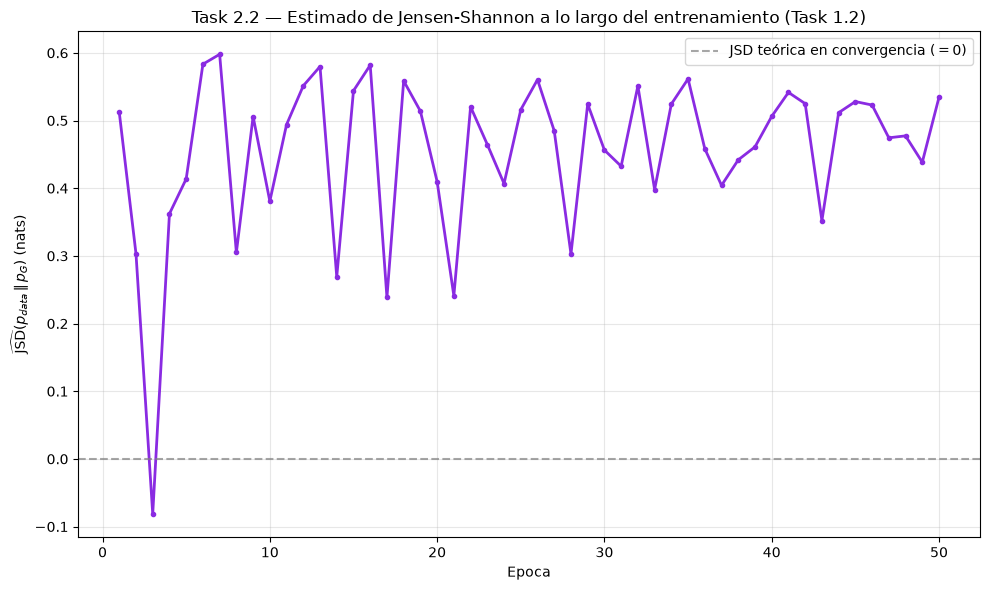

JSD estimado en la primera epoca: 0.5121 nats
JSD estimado en la ultima epoca:  0.5344 nats
JSD minimo observado: -0.0813 nats (epoca 3)


In [14]:
loss_D_hist = np.array(history["loss_D"])
loss_G_hist = np.array(history["loss_G"])
epochs_full = np.arange(1, NUM_EPOCHS + 1)

V_hat = -loss_D_hist                 # V(D, G) estimado por época
jsd_hat = (V_hat + np.log(4)) / 2.0  # JSD estimado (en nats)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_full, jsd_hat, color="#8a2be2", linewidth=2, marker="o", markersize=3)
ax.axhline(0.0, color="gray", linestyle="--", alpha=0.7, label=r"JSD teórica en convergencia ($=0$)")

ax.set_xlabel("Epoca")
ax.set_ylabel(r"$\widehat{\mathrm{JSD}}(p_{data}\,\|\,p_G)$ (nats)")
ax.set_title("Task 2.2 — Estimado de Jensen-Shannon a lo largo del entrenamiento (Task 1.2)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "jsd_estimate.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"JSD estimado en la primera epoca: {jsd_hat[0]:.4f} nats")
print(f"JSD estimado en la ultima epoca:  {jsd_hat[-1]:.4f} nats")
print(f"JSD minimo observado: {jsd_hat.min():.4f} nats (epoca {epochs_full[jsd_hat.argmin()]})")


### Respuestas Task 2.2

**a) ¿En qué dirección sesga el supuesto "$D=D^*$" al estimado?**

El sesgo es hacia la **subestimación**: $\widehat{\text{JSD}}$ calculado con el $D$
real del entrenamiento alternado es, en promedio, **menor o igual** que la JSD
verdadera.

La razón es que, para $p_{data}$ y $p_G$ fijos, $V(D,G)$ es una función de $D$ que se
**maximiza exactamente** en $D=D^*$ (por eso $D^*$ se deriva como
$\arg\max_D V(D,G)$, y por eso la identidad $V(D^*,G)=-\log 4+2\,\text{JSD}$ solo es
válida en ese máximo). Para cualquier discriminador **subóptimo** $D\neq D^*$, como
el $D$ real, que en el training loop del Task 1.2 recibe apenas 1 paso de gradiente
por cada paso de $G$ y nunca converge por completo a su óptimo antes de que $G$
vuelva a moverse, se cumple:

$$
V(D,G) \le V(D^*,G) = -\log 4 + 2\,\text{JSD}(p_{data}\|p_G)
$$

Al despejar, $\widehat{\text{JSD}} = \frac{V(D,G)+\log 4}{2} \le \text{JSD}(p_{data}\|p_G)$.
Es decir, usar un $D$ que no alcanzó a converger a $D^*$ para el $G$ actual siempre
produce un valor de $V(D,G)$ menor (o igual) al verdadero óptimo, y por lo tanto un
$\widehat{\text{JSD}}$ que subestima la divergencia real entre $p_{data}$ y $p_G$.

**b) Valor teórico de convergencia y consistencia con la curva empírica**

Si la GAN converge bien, en el equilibrio de Nash se tiene $p_G=p_{data}$, con lo cual
$\text{JSD}(p_{data}\|p_G)=0$ (dos distribuciones idénticas tienen divergencia nula).
Ese es exactamente el valor visto en clase para $D^*(x)=1/2$ en todas partes, que da
$V(D^*,G^*)=-\log 4$ y por tanto $\widehat{\text{JSD}}\to 0$.

Al revisar la curva empírica de arriba: dado el sesgo hacia la subestimación
explicado en (a), lo esperable es que $\widehat{\text{JSD}}$ se acerque a 0 (o incluso
lo toque/cruce ligeramente por debajo, ya que es una cota inferior con ruido de
muestreo de minibatch) conforme avanzan las épocas, **si y solo si** el entrenamiento
efectivamente se está estabilizando (losses de $G$ y $D$ convergiendo a valores
cercanos, como se identificó en la Task 1.3). Si en cambio la curva se mantiene
alejada de 0, oscila fuertemente, o incluso aumenta hacia el final, es evidencia de
que la red **no alcanzó** el equilibrio teórico en las `NUM_EPOCHS` disponibles, algo
común con datasets pequeños y pocas épocas como en este experimento.

# TASK 3 
---

## Opción C
### Mode collapse y falta de diversidad: Unrolled GANs (Metz et al., 2017)

**Paper:** Luke Metz, Ben Poole, David Pfau, Jascha Sohl-Dickstein. *"Unrolled
Generative Adversarial Networks"*. International Conference on Learning
Representations (ICLR), 2017.

### a) El problema y su formulación matemática

Las GAN originales se entrenan resolviendo, de forma alternada y con pasos de
gradiente locales, el problema minimax

$$G^* = \arg\min_G \max_D V(D,G).$$

El paper señala que esta formulación asume implícitamente que, en cada paso de $G$,
$D$ ya alcanzó su óptimo interno $\max_D V(D,G)$ para el $G$ actual, es decir, que se
puede tratar $f(G) = \max_D V(D,G)$ como el verdadero costo de $G$ y diferenciar a
través de esa maximización. 

En la práctica esto no es viable: por cada actualización de $G$ solo se dan uno o pocos 
pasos de gradiente a $D$, así que $G$ nunca ve el gradiente del $D$ verdaderamente óptimo, 
sino el de un $D$ parcialmente entrenado en un instante fijo. 

Los autores formalizan el mode collapse como consecuencia directa de ese desajuste, 
el gradiente que recibe $G$ en el paso $t$ solo describe cómo "engañar"
al $D_t$ actual, sin anticipar cómo reaccionará $D$ en pasos futuros. Como resultado,
$G$ tiende a colapsar toda la masa de $p_G$ sobre el modo que localmente maximiza
$D_t$, porque desde la perspectiva miope de un solo paso de gradiente, mover todas las
muestras hacia ese único modo es la dirección de descenso más pronunciada, sin
anticipar que $D$ luego aprenderá a rechazar precisamente ese modo. 

Esto reproduce matemáticamente el fenómeno de generadores que oscilan entre unos pocos 
modos en lugar de cubrir toda $p_{data}$.

### b) Modificación propuesta

En vez de usar directamente $D$ en su estado actual $\theta_D$ para computar el
gradiente de $G$, el paper propone **desenrollar** ($\textit{unroll}$) $k$ pasos de
optimización del discriminador dentro del grafo de cómputo, sin aplicarlos
permanentemente a $\theta_D$, y usar el $D$ resultante de esos $k$ pasos hipotéticos
para definir la pérdida del generador. Formalmente, se define una secuencia de
parámetros "simulados"

$$
\theta_D^0 = \theta_D,\qquad
\theta_D^{k} = \theta_D^{k-1} + \eta\,\frac{\partial V(D_{\theta_D^{k-1}}, G)}{\partial \theta_D^{k-1}}
$$

y el objetivo del generador pasa a ser

$$
V_K(D, G) = V\big(D_{\theta_D^K}(\theta_D),\, G\big),
$$

donde $\theta_D^K$ depende diferenciablemente de $\theta_D$ a través de las $k$
actualizaciones simuladas. El gradiente respecto a $\theta_G$ se calcula
retropropagando a través de toda esta cadena de $k$ pasos de $D$
($\nabla_{\theta_G} V_K$), no solo a través del $D$ actual. Con $k=0$ se recupera
exactamente el entrenamiento estándar; con $k$ grande, $G$ se acerca cada vez más al
caso ideal $\max_D V(D,G)$. Esto le da a $G$, en cada actualización, información sobre
cómo reaccionará $D$ ante los cambios que $G$ está a punto de hacer, en lugar de
solo la fotografía instantánea de $D_t$.

### c) Conexión con lo observado experimentalmente en la Parte 2

En el Task 2.1 se indujo mode collapse deliberadamente entrenando $D$ 5 veces más que
$G$, y se observó exactamente el mecanismo que el paper describe: al sobre-entrenar
$D$, este se volvió muy cercano a un óptimo local instantáneo, y el gradiente de $G$
quedó dominado por la única región donde $D$ todavía no estaba saturado
($D(G(z))\approx 0$ en casi todo el resto del espacio, como se justificó en 2.1a).

Todos los $z$ colapsaron hacia esa única grieta del discriminador, produciendo la
grilla de 16 imágenes casi idénticas mostrada en 2.1. En términos del paper, ese es
precisamente el escenario donde $G$ optimiza contra una fotografía miope de $D_t$: al
entrenar $D$ 5 pasos antes de mover $G$ una sola vez, $G$ recibe una señal de
gradiente que ya asume un $D$ mucho más cercano al óptimo de lo que $G$ puede
seguir, sin ninguna anticipación de que $D$ seguirá moviéndose. 

El unrolling ataca esto. Si en el experimento de 2.1 el gradiente de $G$ se hubiese
calculado retropropagando a través de, $k=5$ pasos simulados de $D$, $G$ habría visto
que mover toda su masa hacia el modo que engaña al $D$ actual es una estrategia que
$D$ aprenderá a castigar en los siguientes pasos, y el gradiente resultante habría
repartido la actualización entre varios modos en lugar de concentrarla en uno solo.
Es decir, el mismo desbalance de 5 pasos de $D$ por 1 de $G$ que en el Task 2.1 causó
el colapso es, en espíritu, el escenario que Unrolled GANs neutraliza: en lugar de
prohibir sobre-entrenar $D$, el paper hace que $G$ anticipe ese sobre-entrenamiento
dentro de su propio gradiente.